# Environment  

In [1]:
import os
os.chdir('/Users/burkelawlor/Repos/hci-irae')

import numpy as np
import pandas as pd

import spatialdata as sd
import scanpy as sc
import squidpy as sq
import anndata as ad
from spatialdata_io import xenium

import matplotlib.pyplot as plt
import seaborn as sns

from utils.processing import propogate_subset_labels
from utils.plotting import feature_plots_from_marker_genes, spatial_plot_cell_types_individual, spatial_plot_cell_types_layered

In [2]:
import warnings
from pandas.errors import PerformanceWarning
from anndata import ImplicitModificationWarning

warnings.filterwarnings("ignore", category=PerformanceWarning)
warnings.filterwarnings("ignore", category=ImplicitModificationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Load data

In [14]:
adata_subset = ad.read_h5ad("./data/irae_filtered_annotated_detailed.h5ad")

# Cell annotations

In [4]:
adata_endothelial = adata_subset[adata_subset.obs["cell_type_general"] == "Endothelial"].copy()

sc.pp.pca(adata_endothelial)
sc.pp.neighbors(adata_endothelial)
sc.tl.umap(adata_endothelial)

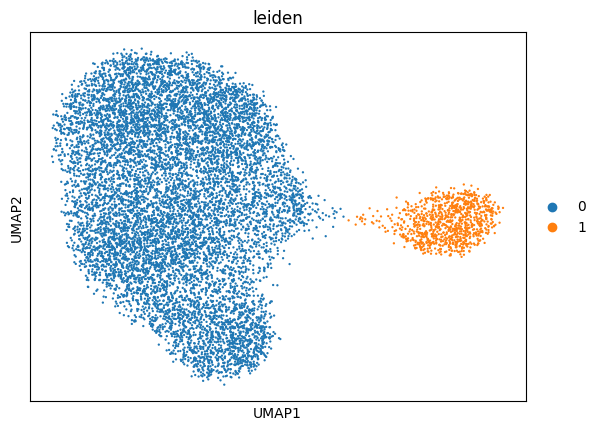

In [5]:
sc.tl.leiden(adata_endothelial, resolution=0.1, flavor="igraph")
sc.tl.dendrogram(adata_endothelial, groupby="leiden")

sc.pl.umap(adata_endothelial, color=["leiden"])

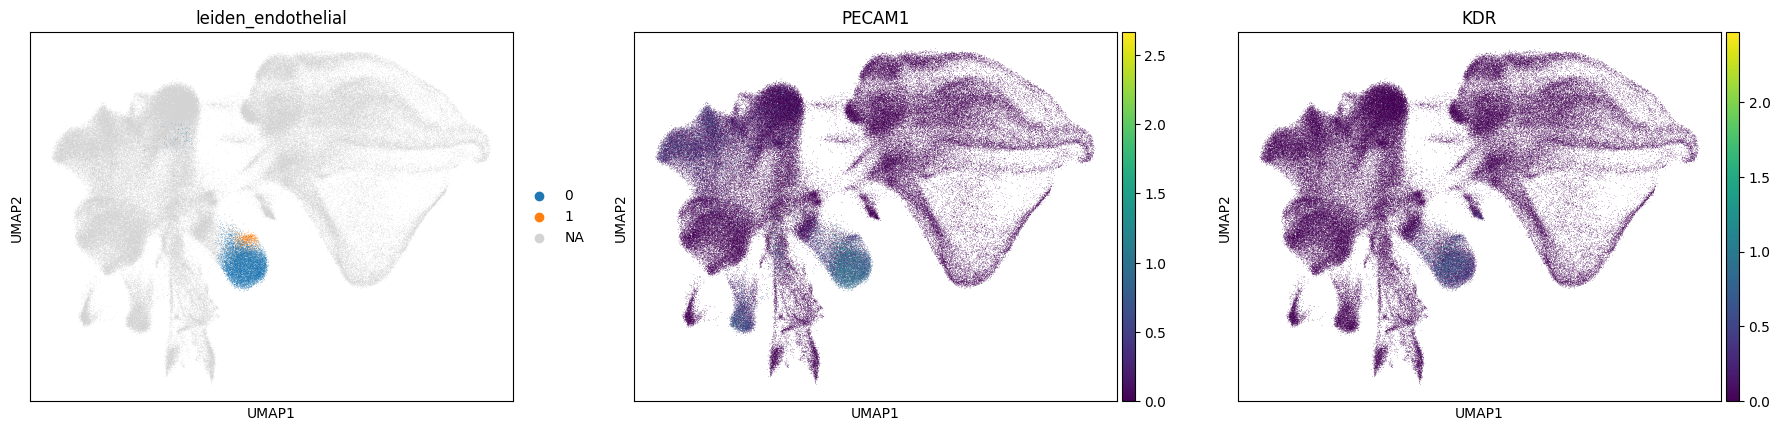

In [6]:
adata_subset = propogate_subset_labels(adata_subset, adata_endothelial, 'leiden_endothelial', 'leiden', 'cell_id_unique')
sc.pl.umap(adata_subset, color=["leiden_endothelial",'PECAM1','KDR'])

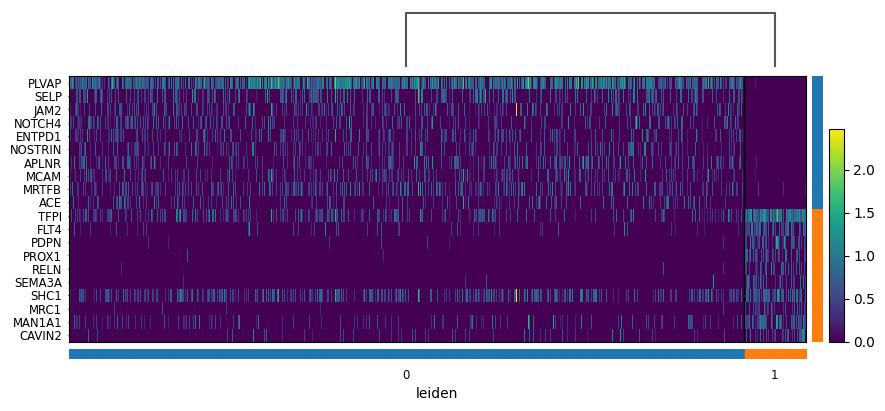

In [7]:
sc.tl.rank_genes_groups(adata_endothelial, groupby='leiden')
sc.tl.dendrogram(adata_endothelial, groupby='leiden')
sc.pl.rank_genes_groups_heatmap(adata_endothelial, groupby='leiden', key='rank_genes_groups', show_gene_labels=True, swap_axes=True)

GENERAL ENDOTHELIAL:


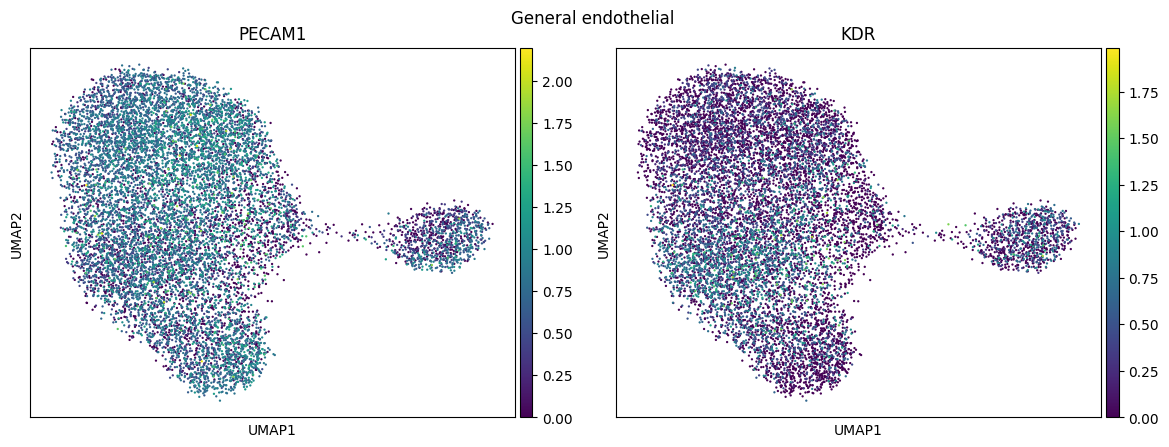

VASCULAR EC:


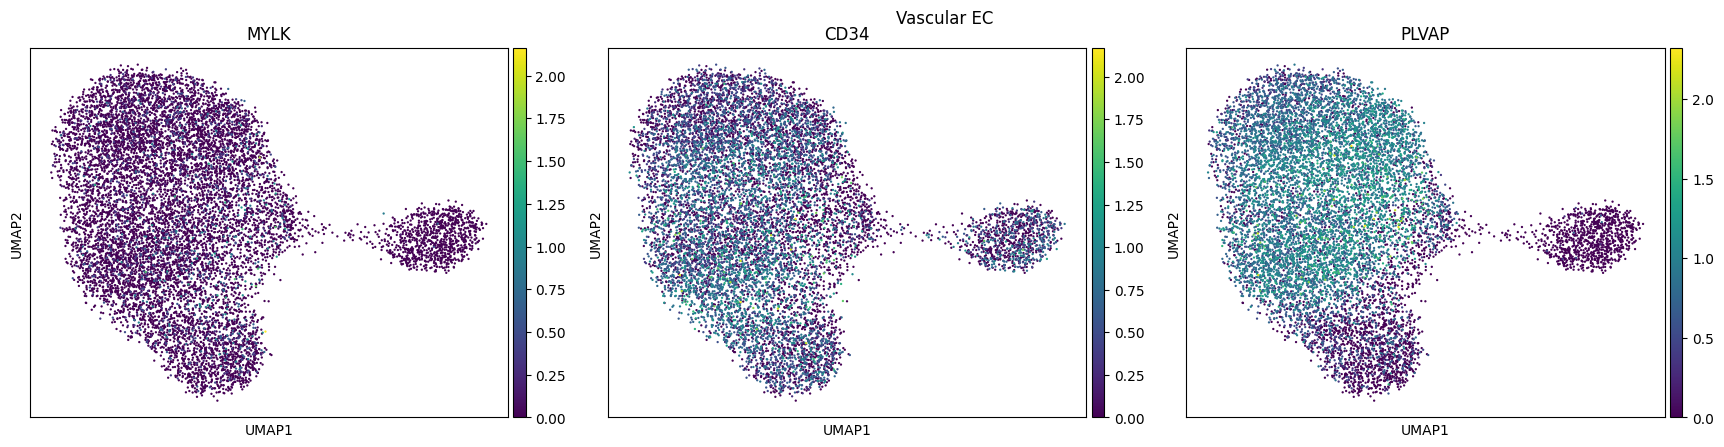

LYMPHATIC EC:


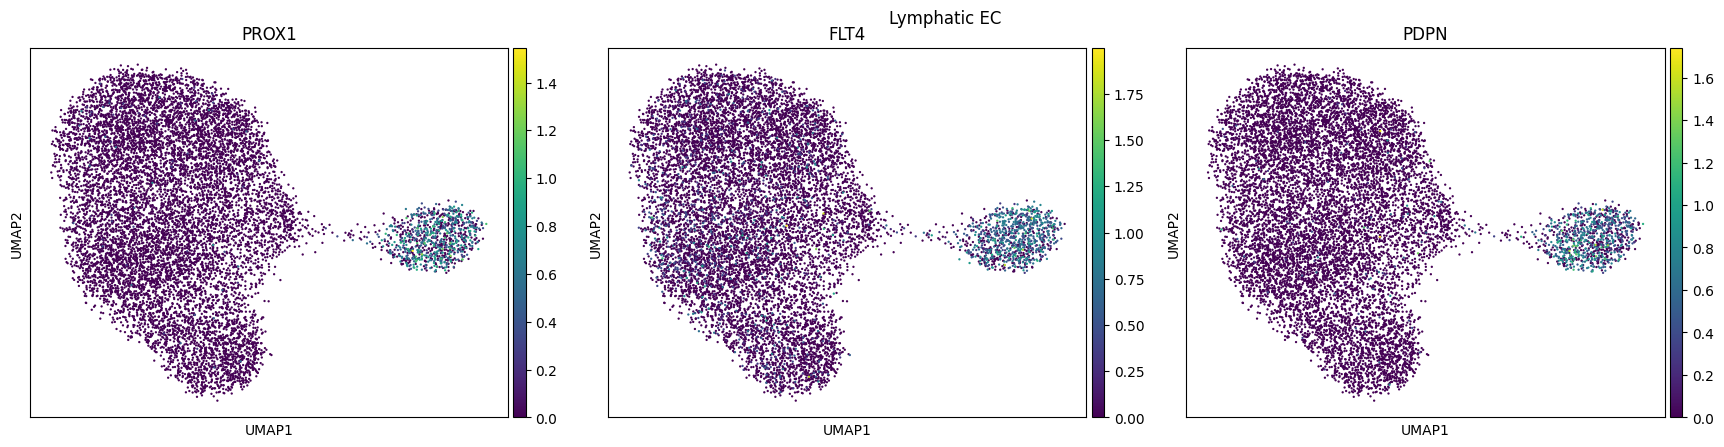

In [8]:
# Source
# He Y, Tacconi C, Dieterich LC, et al. Novel Blood Vascular Endothelial Subtype-Specific Markers in Human Skin Unearthed by Single-Cell Transcriptomic Profiling. Cells. 2022;11(7):1111. doi:10.3390/cells11071111

marker_genes_endothelial = {
    'General endothelial': ['PECAM1','KDR'],
    'Vascular EC': ['MYLK','CD34','PLVAP'],
    'Lymphatic EC': ['PROX1','FLT4','PDPN']
}

feature_plots_from_marker_genes(adata_endothelial, marker_genes_endothelial)

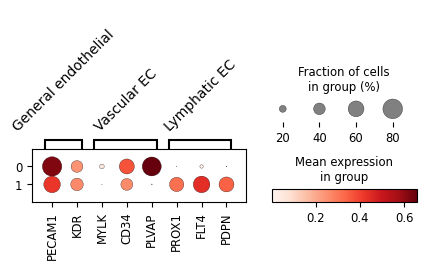

In [9]:
sc.pl.dotplot(adata_endothelial, marker_genes_endothelial, 'leiden', dendrogram=True, var_group_rotation=45)

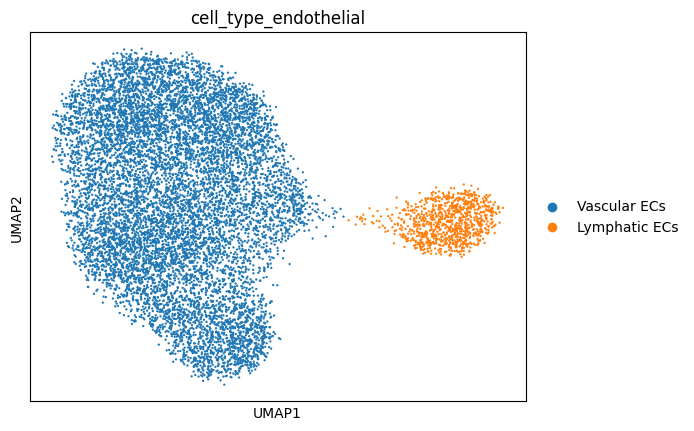

In [10]:
cell_type_endothelial_map = {
    '0': 'Vascular ECs',
    '1': 'Lymphatic ECs',
}

adata_endothelial.obs["cell_type_endothelial"] = adata_endothelial.obs["leiden"].map(cell_type_endothelial_map)

ax = sc.pl.umap(adata_endothelial, color=["cell_type_endothelial"], show=False)# palette=immune_palette_dict)
# ax.figure.savefig("./figures/endothelial_annotation_umap.png", bbox_inches="tight")
# plt.show()

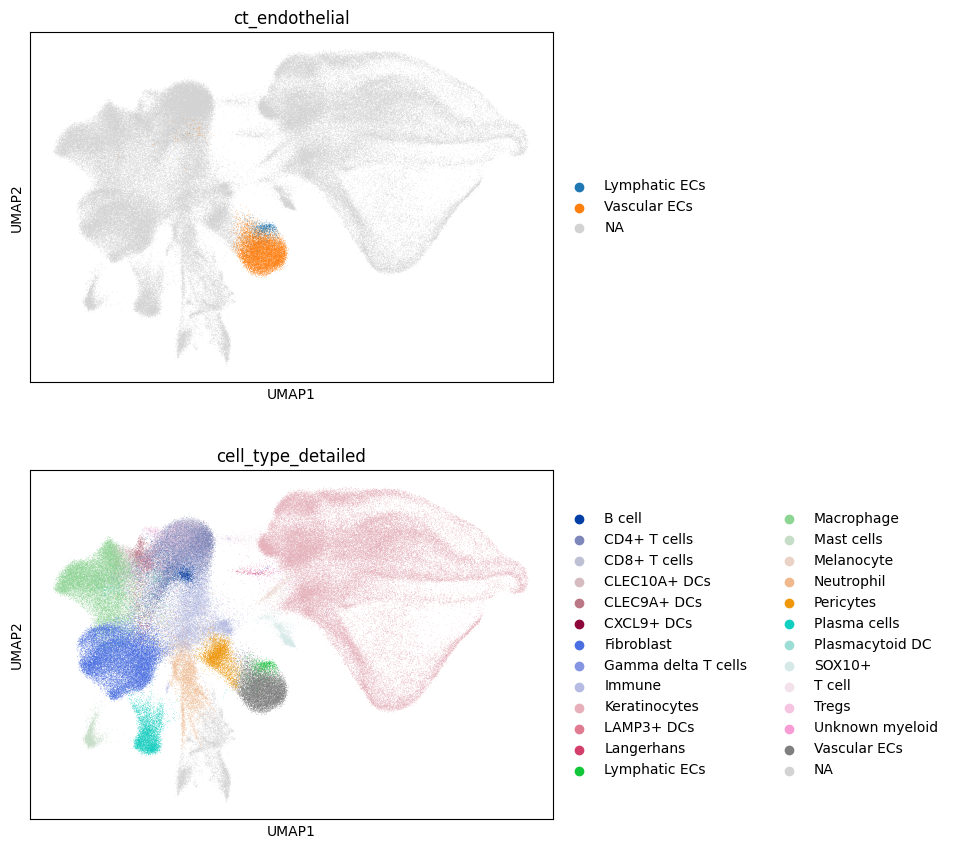

In [15]:
adata_subset = propogate_subset_labels(adata_subset, adata_endothelial, 'ct_endothelial', 'cell_type_endothelial', 'cell_id_unique')
adata_subset = propogate_subset_labels(adata_subset, adata_endothelial, "cell_type_detailed", "cell_type_endothelial", "cell_id_unique")


sc.pl.umap(adata_subset, color=['ct_endothelial', 'cell_type_detailed'], ncols=1)

In [12]:
adata_subset.write_h5ad("./data/irae_filtered_annotated_detailed.h5ad")

# Spatial plots

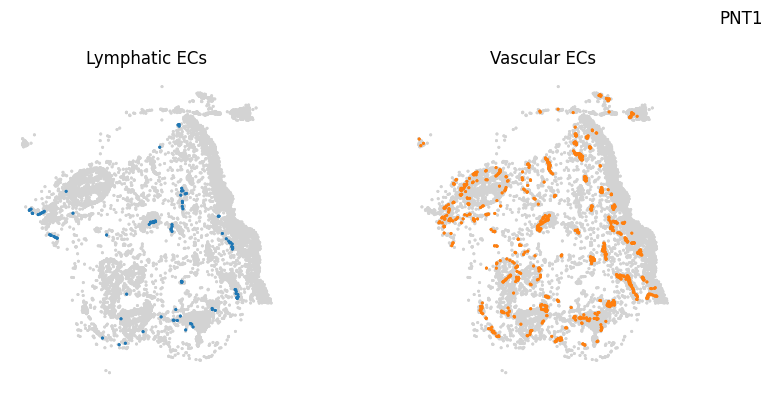

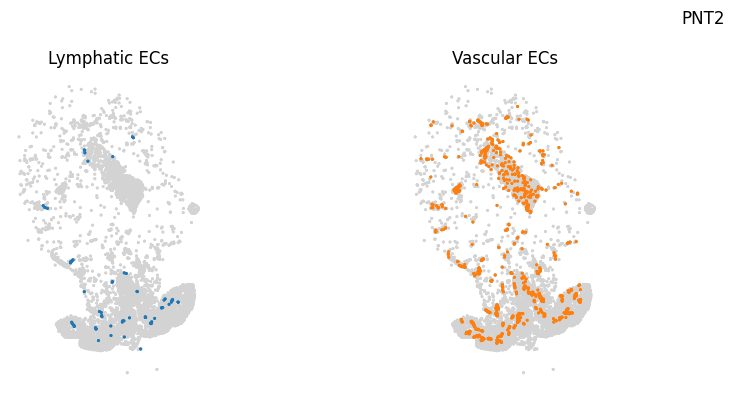

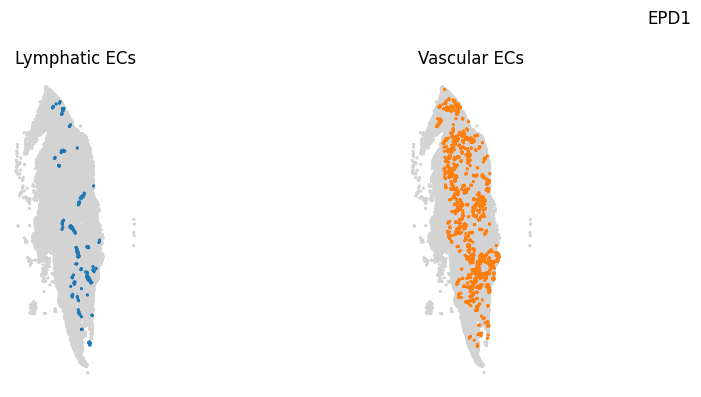

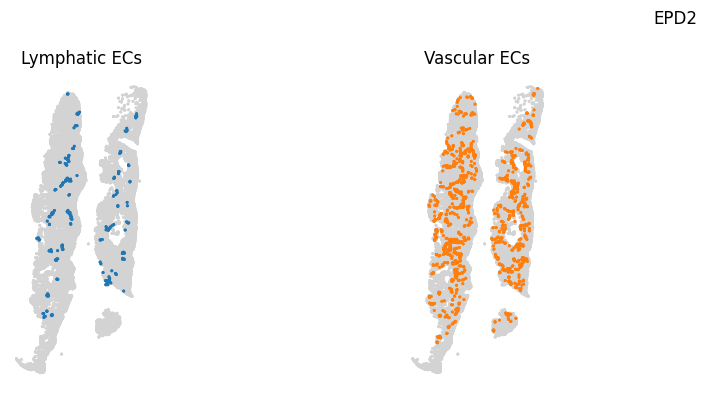

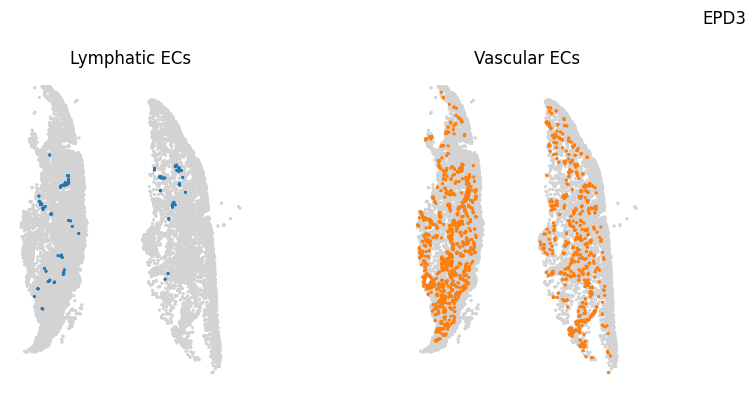

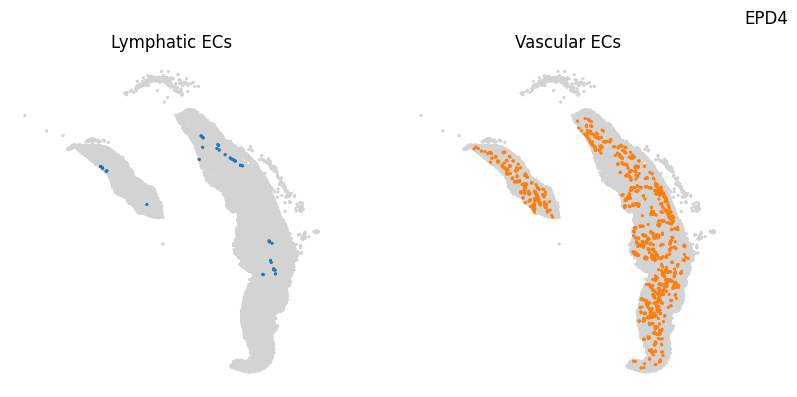

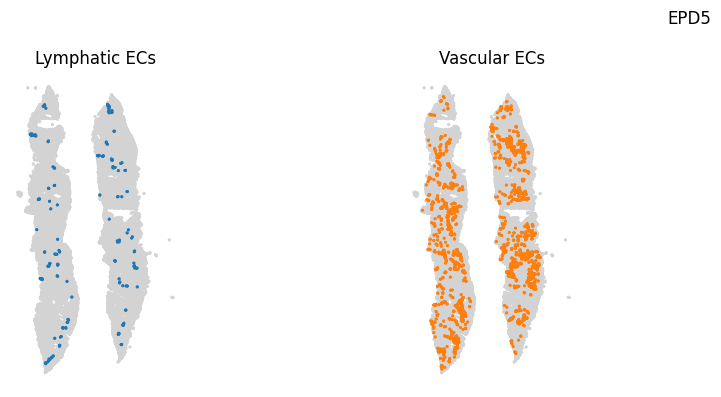

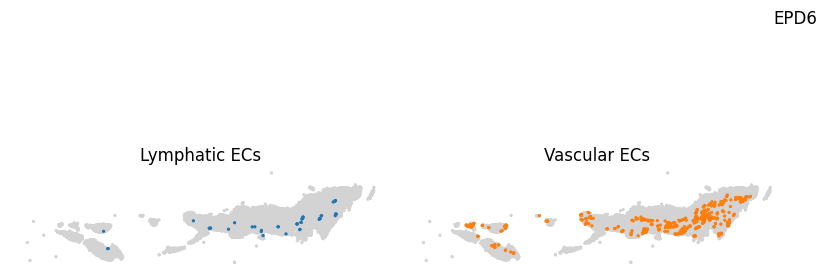

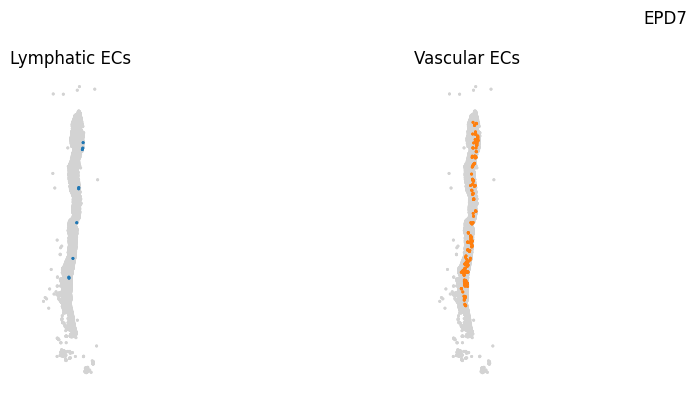

In [13]:
for sample in adata_subset.obs["sample_name"].unique():
    spatial_plot_cell_types_individual(adata_subset, sample, 'ct_endothelial', size=5)